# sklearn model with tensorflow keras tuner

In [ ]:
import sklearn
print(sklearn.__version__)

In [ ]:
import re
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm import tqdm
from textstat import flesch_reading_ease, gunning_fog
import numpy as np

# nltk.download('punkt')
# nltk.download('averaged_perceptron_tagger')
# nltk.download('stopwords')
# nltk.download('vader_lexicon')

def extract_and_aggregate_features(df, text_column):
    """Extracts and aggregates features at the paragraph, sentence, and word levels."""
    # Processing text into paragraphs, sentences, and words
    df['paragraph_lengths'] = df[text_column].apply(lambda x: [len(p.split()) for p in x.split('\n\n') if p.strip()])
    df['sentence_lengths'] = df[text_column].apply(lambda x: [len(s.split()) for s in nltk.sent_tokenize(x)])
    df['word_lengths'] = df[text_column].apply(lambda x: [len(w) for w in x.split()])

    # Aggregating features
    df['paragraph_count'] = df['paragraph_lengths'].apply(len)
    df['sentence_count'] = df['sentence_lengths'].apply(len)
    df['word_count'] = df['word_lengths'].apply(len)

    df['avg_paragraph_length'] = df['paragraph_lengths'].apply(np.mean)
    df['max_paragraph_length'] = df['paragraph_lengths'].apply(max)
    df['min_paragraph_length'] = df['paragraph_lengths'].apply(min)

    df['avg_sentence_length'] = df['sentence_lengths'].apply(np.mean)
    df['max_sentence_length'] = df['sentence_lengths'].apply(max)
    df['min_sentence_length'] = df['sentence_lengths'].apply(min)

    df['avg_word_length'] = df['word_lengths'].apply(np.mean)
    df['max_word_length'] = df['word_lengths'].apply(max)
    df['min_word_length'] = df['word_lengths'].apply(min)

    # Cleaning up DataFrame to remove list columns
    df.drop(['paragraph_lengths', 'sentence_lengths', 'word_lengths'], axis=1, inplace=True)

    return df

def compute_readability_and_sentiment(df, text_column):
    """Computes readability scores and sentiment analysis."""
    df['flesch_reading_ease'] = df[text_column].apply(flesch_reading_ease)
    df['gunning_fog_index'] = df[text_column].apply(gunning_fog)
    sia = SentimentIntensityAnalyzer()
    df['sentiment_score'] = df[text_column].apply(lambda x: sia.polarity_scores(x)['compound'])

    return df


def add_text_features(df, text_column):
    """Main function to aggregate all text processing and feature extraction steps."""
    tqdm.pandas(desc="Extracting and aggregating text features")
    df = extract_and_aggregate_features(df, text_column)
    df = compute_readability_and_sentiment(df, text_column)


    
    return df    

In [ ]:

import wordninja
from nltk.corpus import words

# Load a set of valid English words from NLTK for verification (if needed)
word_list = set(words.words())

def segment_text(text, word_list=word_list):
    """
    Segments concatenated words using wordninja, verifying segmentation with an NLTK words list.

    Args:
    text (str): A string of concatenated words.
    word_list (set): A set containing valid words.

    Returns:
    str: Segmented text, or the original text if segmentation results in less common words.
    """
    segmented_words = wordninja.split(text)
    segmented_text = ' '.join(segmented_words)

    # Optional: verify if the original text is a valid word and if the segmented version introduces less common words
    if text in word_list and not all(word in word_list for word in segmented_words):
        return text
    else:
        return segmented_text



def apply_segmentation(df_chunk, text_col='clean_text'):
    """
    Applies text segmentation to the specified 'text' column of a DataFrame chunk using wordninja.

    Args:
    df_chunk (pd.DataFrame): DataFrame chunk containing a text column with concatenated words.

    Returns:
    pd.DataFrame: DataFrame chunk with a new column 'segmented_text' containing segmented text.
    """
    df_chunk['clean_text'] = df_chunk[text_col].apply(lambda x: segment_text(x))
    return df_chunk

In [ ]:
def clean_text(df, col_name = 'full_text'):
    """
    Preprocesses text for both training and testing datasets. 
    Includes loading embeddings, building vocabularies, cleaning text among other things.
    
    :param summaries_train: DataFrame with the training data
    :param summaries_test: DataFrame with the testing data
    :param glove_path: path to the GloVe embedding
    :param paragram_path: path to the Paragram embedding
    :param wiki_news_path: path to the Wiki News embedding
    
    :return: Preprocessed DataFrame and list of out-of-vocab words
    """
    print("Starting text cleaning process. \n")

    
    # Lowercase all texts

    df['lowered'] = df[col_name].apply(lambda x: x.lower())

    
    
    def clean_spacing(text):
        
        # Remove spaces before punctuation
        text = re.sub(r'\s+([,.!?])', r'\1', text)

        # Ensure there is one space after punctuation
        text = re.sub(r'([,.!?])([^\s])', r'\1 \2', text)

        return text
    

    df['clean_text'] = df['lowered'].apply(lambda x: clean_spacing(x))


        
    punct = "/-'?!.,#$%\'()*+-/:;<=>@[\\]^_`{|}~" + '""“”’' + '∞θ÷α•à−β∅³π‘₹´°£€\×™√²—–&'
    
    punct_mapping = {"‘": "'", "₹": "e", "´": "'", "°": "", "€": "e", "™": "tm", "√": " sqrt ", "×": "x", "²": "2", "—": "-", "–": "-", "’": "'", "_": "-",
                     "`": "'", '“': '"', '”': '"', '“': '"', "£": "e", '∞': 'infinity', 'θ': 'theta', '÷': '/', 'α': 'alpha', '•': '.', 'à': 'a', '−': '-', 
                     'β': 'beta', '∅': '', '³': '3', 'π': 'pi', }

    def clean_special_chars(text, punct, mapping):
        for p in mapping:
            text = text.replace(p, mapping[p])
        for p in punct:
            text = text.replace(p, f' {p} ')
        specials = {'\u200b': ' ', '…': ' ... ', '\ufeff': '', 'करना': '', 'है': ''}  
        for s in specials:
            text = text.replace(s, specials[s])
        return text
    

    df['clean_text'] = df['clean_text'].apply(lambda x: clean_special_chars(x, punct, punct_mapping))

    df['clean_text'] = df['lowered'].apply(lambda x: clean_spacing(x))


    cont_map = {
        "ain't": "am not","aren't": "are not","can't": "cannot","can't've": "cannot have","'cause": "because",  "could've": "could have",
        "couldn't": "could not","couldn't've": "could not have","didn't": "did not","doesn't": "does not","don't": "do not","hadn't": "had not",
        "hadn't've": "had not have","hasn't": "has not",
        "haven't": "have not","he'd": "he would","he'd've": "he would have","he'll": "he will","he'll've": "he will have","he's": "he is",
        "how'd": "how did","how'd'y": "how do you","how'll": "how will","how's": "how is","I'd": "I would","I'd've": "I would have","I'll": "I will",
        "I'll've": "I will have","I'm": "I am","I've": "I have",
        "isn't": "is not","it'd": "it had","it'd've": "it would have","it'll": "it will", "it'll've": "it will have","it's": "it is","let's": "let us",
        "ma'am": "madam","mayn't": "may not",
        "might've": "might have","mightn't": "might not","mightn't've": "might not have","must've": "must have","mustn't": "must not",
        "mustn't've": "must not have","needn't": "need not","needn't've": "need not have","o'clock": "of the clock","oughtn't": "ought not",
        "oughtn't've": "ought not have","shan't": "shall not","sha'n't": "shall not",
        "shan't've": "shall not have","she'd": "she would","she'd've": "she would have","she'll": "she will","she'll've": "she will have","she's": "she is",
        "should've": "should have","shouldn't": "should not","shouldn't've": "should not have","so've": "so have","so's": "so is","that'd": "that would",
        "that'd've": "that would have","that's": "that is","there'd": "there had","there'd've": "there would have","there's": "there is",
        "they'd": "they would","they'd've": "they would have","they'll": "they will","they'll've": "they will have","they're": "they are",
        "they've": "they have","to've": "to have","wasn't": "was not","we'd": "we had",
        "we'd've": "we would have","we'll": "we will","we'll've": "we will have","we're": "we are","we've": "we have",
        "weren't": "were not","what'll": "what will","what'll've": "what will have",
        "what're": "what are","what's": "what is","what've": "what have","when's": "when is","when've": "when have",
        "where'd": "where did","where's": "where is","where've": "where have","who'll": "who will","who'll've": "who will have","who's": "who is",
        "who've": "who have","why's": "why is",
        "why've": "why have","will've": "will have","won't": "will not","won't've": "will not have","would've": "would have","wouldn't": "would not",
        "wouldn't've": "would not have","y'all": "you all","y'alls": "you alls","y'all'd": "you all would",
        "y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have","you'd": "you had","you'd've": "you would have",
        "you'll": "you you will","you'll've": "you you will have","you're": "you are",  "you've": "you have"}

    c_re = re.compile('(%s)' % '|'.join(cont_map.keys()))

    def expandContractions(text, c_re=c_re):
        def replace(match):
            return cont_map[match.group(0)]
        return c_re.sub(replace, text)


#     p = inflect.engine()

    def removeHTML(text):
        """
        Remove HTML tags from a given text string using regex.
    
        Args:
            text (str): The input text string containing HTML tags.
    
        Returns:
            str: The text string with HTML tags removed.
        """
        html = re.compile(r'<.*?>')
        return html.sub('', text)

    def dataPreprocessing(text):
        """
        Process the input text to perform a series of cleaning and formatting tasks,
        including converting numbers to words, removing specific patterns and whitespace,
        and stripping unwanted characters.
    
        Args:
            text (str): The input text string to preprocess.
    
        Returns:
            str: The cleaned and formatted text.
        """
        text = text.lower()
        text = removeHTML(text)
        # text = re.sub(r'\d+', lambda match: p.number_to_words(match.group()) + " ", text)  # Add spaces around the number words
        text = re.sub(r'\s+', ' ', text)  # Normalize multiple spaces to a single space
        text = re.sub(r"@\w+", '', text)
        text = re.sub(r"'\d+", '', text)
        text = re.sub(r"\d+", '', text)
        text = re.sub(r"http\w+", '', text)
        text = re.sub(r"[-_]+", " ", text)  # Replace hyphens and underscores with space
        text = expandContractions(text)
        text = re.sub(r"\.+", ".", text)
        text = re.sub(r"\,+", ",", text)
        text = re.sub(r"[^\w\s]", "", text)  # Remove all non-alphanumeric and non-space characters
        text = re.sub(r"\s+", " ", text)    # Normalize multiple spaces to a single space

        text = text.strip()

        return text

    
    df['clean_text'] = df['clean_text'].apply(lambda x: dataPreprocessing(x))
    
    # Step 8: Generate combined dense vector for each row of text
    
    # df['combined_dense_vector'] = df['clean_text'].apply(lambda x: get_combined_dense_vector(x, embeddings))

    # # Expand the combined dense vector into separate columns
    
    # combined_df = pd.DataFrame(list(df['combined_dense_vector']), 
    #                            columns=[f"dense_vec_{i}" for i in range(df['combined_dense_vector'][0].size)])

    # # Concatenate this new DataFrame with the original DataFrame
    
    # df = pd.concat([df, combined_df], axis=1)

    # # Step 9: Add TF-IDF features to the corrected text
    
    # df.drop(columns=['combined_dense_vector'], inplace=True)
    
    print('Adding Text Features................. \n')
    
    df = add_text_features(df, 'full_text')

    print('Complete................. \n')
    
    return df

In [ ]:
import sklearn
print(sklearn.__version__)

In [ ]:
laptop = False

if laptop:
    csv_path = '/home/laptop/github/kaggle/scoring/xlnet_hash.csv'

if not laptop:
    csv_path = '/home/jack/github/kaggle/scoring/data/trainining_full (2).csv'

In [ ]:
pd.set_option('display.max_columns', None)

deberta_full = pd.read_csv(csv_path)

# deberta_full.drop(columns=['clean_text', 'score', 'labels'], inplace=True, axis=1)

deberta_full.drop(columns=['full_text', 'score'], inplace=True, axis=1)

deberta_full.head()

In [ ]:
# set file paths for either laptop or desktop

if laptop:

    file_config = {

        'vectorizer': '/home/laptop/github/kaggle/scoring/model_data/sklearn/vectorizer.pkl',
        'lda_model': '/home/laptop/github/kaggle/scoring/model_data/sklearn/lda_model.pkl',
        'tf_vectorizer': '/home/laptop/github/kaggle/scoring/model_data/sklearn/tf_vectorizer.pkl',
        'feature_cols': '/home/laptop/github/kaggle/scoring/model_data/sklearn/feature_cols.txt',
        'scaler': '/home/laptop/github/kaggle/scoring/model_data/sklearn/scaler.pkl',   
        'top_corelations': '/home/laptop/github/kaggle/scoring/model_data/sklearn/top_corelations.txt',
        'sklearn_model': '/home/laptop/github/kaggle/scoring/model_data/sklearn/sklearn_model.joblib'}
    
if not laptop:

    file_config = {
        'vectorizer': '/home/jack/github/kaggle/scoring/model_data/sklearn/vectorizer.pkl',
        'lda_model': '/home/jack/github/kaggle/scoring/model_data/sklearn/lda_model.pkl',
        'tf_vectorizer': '/home/jack/github/kaggle/scoring/model_data/sklearn/tf_vectorizer.pkl',
        'feature_cols': '/home/jack/github/kaggle/scoring/model_data/sklearn/feature_cols.txt',
        'scaler': '/home/jack/github/kaggle/scoring/model_data/sklearn/scaler.pkl',   
        'top_corelations': '/home/jack/github/kaggle/scoring/model_data/sklearn/top_corelations.txt',
        'sklearn_model': '/home/jack/github/kaggle/scoring/model_data/sklearn/sklearn_model.joblib'}
    




In [ ]:
if laptop:
    csv_path = '/home/laptop/github/kaggle/scoring/data/train.csv'

if not laptop:
    csv_path = '/home/jack/github/kaggle/scoring/data/train.csv'

In [ ]:
train = pd.read_csv(csv_path)

In [ ]:
train = clean_text(train)

train.head()

In [ ]:
print(deberta_full.shape, train.shape)

In [ ]:
# Combine train and deberta_full on essay_id

train = train.merge(deberta_full, on='essay_id')

In [ ]:
train.head()

In [ ]:
print(train.shape)

In [ ]:
import pandas as pd
import textwrap

# Function to format and print the text
def print_formatted_text(df, column_name, index, width=70):
    """
    Print the text from a specified column and row in a formatted and wrapped manner.

    Args:
        df (pd.DataFrame): The DataFrame containing the text data.
        column_name (str): The name of the column containing the text.
        index (int): The index of the row to print.
        width (int, optional): The maximum width of each line. Defaults to 70.
    """
    if index < 0 or index >= len(df):
        print(f"Index {index} is out of bounds for DataFrame with length {len(df)}.")
        return

    wrapped_text = textwrap.fill(df.at[index, column_name], width=width)
    print(f"Text at index {index}:\n{wrapped_text}\n")



In [ ]:
# Usage
print_formatted_text(train, 'full_text', 0 ,  width=50)

In [ ]:
print_formatted_text(train, 'clean_text', 0 ,  width=50)

In [ ]:
df = train.copy()

In [ ]:
# from sklearn.feature_extraction.text import CountVectorizer
# import pandas as pd
# import dill
# import spacy

# # Initialize a CountVectorizer with n-gram range from 1 to 3 (unigrams to trigrams)
# vectorizer = CountVectorizer(ngram_range=(1, 3), max_features=1000, stop_words='english')

# # Initialize and fit the vectorizer
# X_ngrams = vectorizer.fit_transform(df['full_text'])
# df_ngrams = pd.DataFrame(X_ngrams.toarray(), columns=vectorizer.get_feature_names_out())

# # Save the vectorizer
# with open('/home/laptop/github/kaggle/scoring/model_data/sklearn/vectorizer.pkl', 'wb') as f:
#     dill.dump(vectorizer, f)

# # Load the spaCy model
# nlp = spacy.load("en_core_web_sm")

# # Function to count POS tags
# def pos_counts(text):
#     doc = nlp(text)
#     total_tokens = len(doc)
#     pos_counts = doc.count_by(spacy.attrs.POS)
#     return {f'pos_{doc.vocab.strings[pos_id]}': count / total_tokens for pos_id, count in pos_counts.items() if total_tokens > 0}

# # Function to count Named Entities
# def named_entities(text):
#     doc = nlp(text)
#     total_tokens = len(doc)
#     entities = {}
#     for ent in doc.ents:
#         entities[ent.label_] = entities.get(ent.label_, 0) + 1
#     return {f'ner_{label}': count / total_tokens for label, count in entities.items() if total_tokens > 0}

# # Function to count Dependency Tags
# def dependency_tags(text):
#     doc = nlp(text)
#     total_tokens = len(doc)
#     dep_counts = doc.count_by(spacy.attrs.DEP)
#     return {f'dep_{doc.vocab.strings[dep_id]}': count / total_tokens for dep_id, count in dep_counts.items() if total_tokens > 0}

# # Define all possible columns
# all_pos_cols = [f'pos_{pos}' for pos in nlp.get_pipe("tagger").labels]
# all_ent_cols = [f'ner_{ent}' for ent in nlp.get_pipe("ner").labels]
# all_dep_cols = [f'dep_{dep}' for dep in nlp.get_pipe("parser").labels]

# # Extract POS tags, named entities, and dependency tags
# df_pos = df['full_text'].apply(pos_counts).apply(pd.Series).fillna(0)
# df_entities = df['full_text'].apply(named_entities).apply(pd.Series).fillna(0)
# df_deps = df['full_text'].apply(dependency_tags).apply(pd.Series).fillna(0)

# # Ensure all POS, NER, and Dependency columns are present
# for col_list, df_features in [(all_pos_cols, df_pos), (all_ent_cols, df_entities), (all_dep_cols, df_deps)]:
#     for col in col_list:
#         if col not in df_features.columns:
#             df_features[col] = 0

# # Sort columns for consistency
# df_pos = df_pos[sorted(df_pos.columns)]
# df_entities = df_entities[sorted(df_entities.columns)]
# df_deps = df_deps[sorted(df_deps.columns)]

# # Concatenate all feature DataFrames with the original DataFrame
# df = pd.concat([df.reset_index(drop=True), df_ngrams.reset_index(drop=True), 
#                          df_pos.reset_index(drop=True), df_entities.reset_index(drop=True), 
#                          df_deps.reset_index(drop=True)], axis=1)


In [ ]:
# import pandas as pd
# import dill
# import spacy
# import re
# from collections import Counter
# from sklearn.decomposition import LatentDirichletAllocation
# from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
# from sentence_transformers import SentenceTransformer
# from nltk.corpus import stopwords
# from spellchecker import SpellChecker
# import textstat

# # Load spaCy model
# nlp = spacy.load("en_core_web_sm")
# stop_words = set(stopwords.words('english'))
# sentiment_analyzer = SentimentIntensityAnalyzer()
# spell = SpellChecker()
# bert_model = SentenceTransformer('all-MiniLM-L6-v2')

# text_col = 'clean_text'

# # Define feature extraction functions
# def pos_counts(text):
#     doc = nlp(text)
#     pos_counts = doc.count_by(spacy.attrs.POS)
#     return {f'pos_{doc.vocab.strings[pos_id]}': count for pos_id, count in pos_counts.items()}

# def named_entities(text):
#     doc = nlp(text)
#     entities = {ent.label_: ent for ent in doc.ents}
#     return {f'ner_{label}': count for label, count in entities.items()}

# def dependency_tags(text):
#     doc = nlp(text)
#     dep_counts = doc.count_by(spacy.attrs.DEP)
#     return {f'dep_{doc.vocab.strings[dep_id]}': count for dep_id, count in dep_counts.items()}

# def compute_linguistic_features(text):
#     doc = nlp(text)
#     tenses = [token.tag_ for token in doc if token.pos_ == "VERB"]
#     tense_counts = Counter(tenses)
#     most_common_tense = tense_counts.most_common(1)[0][0] if tense_counts else None
#     verb_tense_consistency = tense_counts[most_common_tense] / len(tenses) if tenses else 0
#     passive_count = sum(1 for token in doc if token.dep_ == "nsubjpass")
#     passive_voice_usage = passive_count / len([token for token in doc if token.pos_ == "VERB"]) if doc else 0
#     modal_verbs = {"can", "could", "will", "would", "shall", "should", "may", "might", "must"}
#     modal_count = sum(1 for token in doc if token.lemma_ in modal_verbs)
#     modal_verb_usage = modal_count / len(doc) if doc else 0
#     lexical_diversity = len(set(doc)) / len(doc) if doc else 0
#     dale_chall_readability = textstat.dale_chall_readability_score(text)
#     automated_readability_index = textstat.automated_readability_index(text)
#     coleman_liau_index = textstat.coleman_liau_index(text)
#     conjunction_count = sum(1 for token in doc if token.pos_ in {"CCONJ", "SCONJ"})
#     clause_count = sum(1 for token in doc if token.dep_ in {"csubj", "advcl", "ccomp", "xcomp"})
#     clause_density = clause_count / max(len([token for token in doc if token.dep_ in {"ROOT", "nsubj"}]), 1)
#     return {
#         "verb_tense_consistency": verb_tense_consistency,
#         "passive_voice_usage": passive_voice_usage,
#         "modal_verb_usage": modal_verb_usage,
#         "lexical_diversity": lexical_diversity,
#         "dale_chall_readability": dale_chall_readability,
#         "automated_readability_index": automated_readability_index,
#         "coleman_liau_index": coleman_liau_index,
#         "conjunction_usage": conjunction_count,
#         "clause_density": clause_density
#     }

# def compute_sentiment_features(text):
#     sentiment_scores = sentiment_analyzer.polarity_scores(text)
#     return {
#         "vader_compound": sentiment_scores["compound"],
#         "vader_positive": sentiment_scores["pos"],
#         "vader_negative": sentiment_scores["neg"],
#         "vader_neutral": sentiment_scores["neu"]
#     }

# def extract_bert_embedding(text):
#     embedding = bert_model.encode([text])[0]
#     return {f'bert_dim_{i}': value for i, value in enumerate(embedding)}

# def extract_topic_features(text, lda_model, vectorizer):
#     text_vector = vectorizer.transform([text])
#     topic_distribution = lda_model.transform(text_vector)[0]
#     return {f'topic_{i}': prob for i, prob in enumerate(topic_distribution)}

# def extract_spelling_grammar_errors(text):
#     misspelled = spell.unknown(text.split())
#     return {
#         "spelling_errors": len(misspelled),
#         "grammar_errors": sum(1 for token in nlp(text) if token.dep_ == "pcomp")
#     }

# def compute_advanced_readability_scores(text):
#     return {
#         "linsear_write_formula": textstat.linsear_write_formula(text),
#         "ari_score": textstat.automated_readability_index(text),
#     }

# def apply_feature_extraction(df, lda_model, vectorizer):
#     df_pos = df[text_col].apply(pos_counts).apply(pd.Series).fillna(0)
#     df_entities = df[text_col].apply(named_entities).apply(pd.Series).fillna(0)
#     df_deps = df[text_col].apply(dependency_tags).apply(pd.Series).fillna(0)
#     df_linguistic = df[text_col].apply(compute_linguistic_features).apply(pd.Series)
#     df_sentiment = df[text_col].apply(compute_sentiment_features).apply(pd.Series)
#     df_bert = df[text_col].apply(extract_bert_embedding).apply(pd.Series)
#     df_topics = df[text_col].apply(lambda x: extract_topic_features(x, lda_model, vectorizer)).apply(pd.Series)
#     df_spelling_grammar = df[text_col].apply(extract_spelling_grammar_errors).apply(pd.Series)
#     df_readability = df[text_col].apply(compute_advanced_readability_scores).apply(pd.Series)
#     return pd.concat([df.reset_index(drop=True), df_pos.reset_index(drop=True), 
#                       df_entities.reset_index(drop=True), df_deps.reset_index(drop=True), 
#                       df_linguistic.reset_index(drop=True), df_sentiment.reset_index(drop=True),
#                       df_bert.reset_index(drop=True), df_topics.reset_index(drop=True),
#                       df_spelling_grammar.reset_index(drop=True),
#                       df_readability.reset_index(drop=True)], axis=1)

# # Train LDA topic model
# tf_vectorizer = TfidfVectorizer(max_features=200, stop_words='english')
# tf = tf_vectorizer.fit_transform(df[text_col])
# lda_model = LatentDirichletAllocation(n_components=10, random_state=42)
# lda_model.fit(tf)

# # Apply feature extraction
# df_train_features = apply_feature_extraction(df, lda_model, tf_vectorizer)

# # Save the LDA model and vectorizers
# with open('/home/jack/github/kaggle/scoring/model_data/sklearn/lda_model.pkl', 'wb') as f:
#     dill.dump(lda_model, f)
# with open('/home/jack/github/kaggle/scoring/model_data/sklearn/vectorizer.pkl', 'wb') as f:
#     dill.dump(vectorizer, f)
# with open('/home/jack/github/kaggle/scoring/model_data/sklearn/tf_vectorizer.pkl', 'wb') as f:
#     dill.dump(tf_vectorizer, f)

# # Initialize and fit the CountVectorizer for n-grams
# X_ngrams_train = vectorizer.fit_transform(df[text_col])
# df_ngrams_train = pd.DataFrame(X_ngrams_train.toarray(), columns=vectorizer.get_feature_names_out())

# # Combine all features
# df_train_combined = pd.concat([df_train_features.reset_index(drop=True), df_ngrams_train.reset_index(drop=True)], axis=1)
# df = df_train_combined.copy()


In [ ]:
import pandas as pd
import dill
import spacy
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sentence_transformers import SentenceTransformer
from nltk.corpus import stopwords
from spellchecker import SpellChecker
import textstat
from collections import Counter

# Load spaCy model
nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words('english'))
sentiment_analyzer = SentimentIntensityAnalyzer()
spell = SpellChecker()
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

text_col = 'full_text'

# Initialize a CountVectorizer with n-gram range from 1 to 3 (unigrams to trigrams)
vectorizer = CountVectorizer(ngram_range=(1, 3), max_features=500, stop_words='english')

# Initialize and fit the vectorizer
X_ngrams_train = vectorizer.fit_transform(df[text_col])
df_ngrams_train = pd.DataFrame(X_ngrams_train.toarray(), columns=vectorizer.get_feature_names_out())

# Save the vectorizer
with open(file_config['vectorizer'], 'wb') as f:
    dill.dump(vectorizer, f)

# Train LDA topic model

# tf_vectorizer = TfidfVectorizer(max_features=200, stop_words='english')
# tf = tf_vectorizer.fit_transform(df[text_col])

# lda_model = LatentDirichletAllocation(n_components=10, random_state=42)
# lda_model.fit(tf)

# Save the LDA model and vectorizers

# with open(file_config['lda_model'], 'wb') as f:
#     dill.dump(lda_model, f)
    
# with open(file_config['tf_vectorizer'], 'wb') as f:
#     dill.dump(tf_vectorizer, f)

# Define feature extraction functions
def pos_counts(text):
    doc = nlp(text)
    total_tokens = len(doc)
    pos_counts = doc.count_by(spacy.attrs.POS)
    pos_features = {f'pos_{doc.vocab.strings[pos_id]}_count': count for pos_id, count in pos_counts.items()}
    pos_ratios = {f'pos_{doc.vocab.strings[pos_id]}_ratio': count / total_tokens for pos_id, count in pos_counts.items() if total_tokens > 0}
    return {**pos_features, **pos_ratios}

def named_entities(text):
    doc = nlp(text)
    total_tokens = len(doc)
    entities = {}
    for ent in doc.ents:
        entities[ent.label_] = entities.get(ent.label_, 0) + 1
    entity_features = {f'ner_{label}_count': count for label, count in entities.items()}
    entity_ratios = {f'ner_{label}_ratio': count / total_tokens for label, count in entities.items() if total_tokens > 0}
    return {**entity_features, **entity_ratios}

def dependency_tags(text):
    doc = nlp(text)
    total_tokens = len(doc)
    dep_counts = doc.count_by(spacy.attrs.DEP)
    dep_features = {f'dep_{doc.vocab.strings[dep_id]}_count': count for dep_id, count in dep_counts.items()}
    dep_ratios = {f'dep_{doc.vocab.strings[dep_id]}_ratio': count / total_tokens for dep_id, count in dep_counts.items() if total_tokens > 0}
    return {**dep_features, **dep_ratios}

def compute_linguistic_features(text):
    doc = nlp(text)
    tenses = [token.tag_ for token in doc if token.pos_ == "VERB"]
    tense_counts = Counter(tenses)
    most_common_tense = tense_counts.most_common(1)[0][0] if tense_counts else None
    verb_tense_consistency = tense_counts[most_common_tense] / len(tenses) if tenses else 0

    verbs = [token for token in doc if token.pos_ == "VERB"]
    passive_count = sum(1 for token in doc if token.dep_ == "nsubjpass")
    passive_voice_usage = passive_count / len(verbs) if verbs else 0

    modal_verbs = {"can", "could", "will", "would", "shall", "should", "may", "might", "must"}
    modal_count = sum(1 for token in doc if token.lemma_ in modal_verbs)
    modal_verb_usage = modal_count / len(doc) if len(doc) > 0 else 0

    lexical_diversity = len(set(doc)) / len(doc) if len(doc) > 0 else 0

    dale_chall_readability = textstat.dale_chall_readability_score(text)
    automated_readability_index = textstat.automated_readability_index(text)
    coleman_liau_index = textstat.coleman_liau_index(text)

    conjunction_count = sum(1 for token in doc if token.pos_ in {"CCONJ", "SCONJ"})
    clause_count = sum(1 for token in doc if token.dep_ in {"csubj", "advcl", "ccomp", "xcomp"})
    clause_density = clause_count / max(len([token for token in doc if token.dep_ in {"ROOT", "nsubj"}]), 1)

    return {
        "verb_tense_consistency": verb_tense_consistency,
        "passive_voice_usage": passive_voice_usage,
        "modal_verb_usage": modal_verb_usage,
        "lexical_diversity": lexical_diversity,
        "dale_chall_readability": dale_chall_readability,
        "automated_readability_index": automated_readability_index,
        "coleman_liau_index": coleman_liau_index,
        "conjunction_usage": conjunction_count,
        "clause_density": clause_density
    }

def compute_sentiment_features(text):
    sentiment_scores = sentiment_analyzer.polarity_scores(text)
    return {
        "vader_compound": sentiment_scores["compound"],
        "vader_positive": sentiment_scores["pos"],
        "vader_negative": sentiment_scores["neg"],
        "vader_neutral": sentiment_scores["neu"]
    }

def extract_bert_embedding(text):
    embedding = bert_model.encode([text])[0]
    return {f'bert_dim_{i}': value for i, value in enumerate(embedding)}

def extract_topic_features(text, lda_model, vectorizer):
    text_vector = vectorizer.transform([text])
    topic_distribution = lda_model.transform(text_vector)[0]
    return {f'topic_{i}': prob for i, prob in enumerate(topic_distribution)}

def extract_spelling_grammar_errors(text):
    misspelled = spell.unknown(text.split())
    return {
        "spelling_errors": len(misspelled),
        "grammar_errors": sum(1 for token in nlp(text) if token.dep_ == "pcomp")
    }

def compute_advanced_readability_scores(text):
    return {
        "linsear_write_formula": textstat.linsear_write_formula(text),
        "ari_score": textstat.automated_readability_index(text),
    }

def apply_feature_extraction(df, lda_model=None, vectorizer=None):
    df_pos = df[text_col].apply(pos_counts).apply(pd.Series).fillna(0)
    df_entities = df[text_col].apply(named_entities).apply(pd.Series).fillna(0)
    df_deps = df[text_col].apply(dependency_tags).apply(pd.Series).fillna(0)
    # df_linguistic = df[text_col].apply(compute_linguistic_features).apply(pd.Series)
    # df_sentiment = df[text_col].apply(compute_sentiment_features).apply(pd.Series)

    # df_bert = df[text_col].apply(extract_bert_embedding).apply(pd.Series)
    # df_topics = df[text_col].apply(lambda x: extract_topic_features(x, lda_model, vectorizer)).apply(pd.Series)

    df_spelling_grammar = df[text_col].apply(extract_spelling_grammar_errors).apply(pd.Series)
    df_readability = df[text_col].apply(compute_advanced_readability_scores).apply(pd.Series)
    
    return pd.concat([df.reset_index(drop=True), df_pos.reset_index(drop=True), 
                      df_entities.reset_index(drop=True), df_deps.reset_index(drop=True), 
                    #   df_linguistic.reset_index(drop=True), df_sentiment.reset_index(drop=True),
                      df_spelling_grammar.reset_index(drop=True),
                      df_readability.reset_index(drop=True)], axis=1)    # df_bert.reset_index(drop=True), df_topics.reset_index(drop=True)
                      

# Apply feature extraction
df_train_features = apply_feature_extraction(df) # , lda_model, tf_vectorizer)

# Combine all features
df_train_combined = pd.concat([df_train_features.reset_index(drop=True), df_ngrams_train.reset_index(drop=True)], axis=1)

df = df_train_combined.copy()

In [ ]:
df.head()

In [ ]:

# Import necessary libraries
import pandas as pd
from itertools import combinations

# Assuming the DataFrame `df` and `score` are already defined
# and excluding irrelevant columns

# Calculate correlations with the target

cor = df.drop(columns=['essay_id', 'full_text', 'clean_text', 'lowered' , 'score'], axis=1) # ,'processed_docs', 'topics',

correlations = cor.corrwith(df['score']).sort_values(ascending=False)



# Set a correlation threshold or select top N features
correlation_threshold = 0.3

top_features = correlations[abs(correlations) > correlation_threshold].index.tolist()

# Print the most correlated features
print("Top correlations with the score:")
print(top_features)

# Generate interaction terms between pairs of top features
for feature1, feature2 in combinations(top_features, 2):
    df[f'interaction_{feature1}_{feature2}'] = df[feature1] * df[feature2]


# Optional: print the list of created interaction terms
interaction_terms = [f'interaction_{feature1}_{feature2}' for feature1, feature2 in combinations(top_features, 2)]
print("Created interaction terms:")
print(interaction_terms)


# export top_features to text file

with open('/home/jack/github/kaggle/scoring/model_data/sklearn/top_corelations.txt', 'w') as f:
    for item in top_features:
        f.write("%s\n" % item)


In [ ]:
df.head()

In [ ]:
df.tail()


In [ ]:
# drop columns with hash in the name

hash_cols = [col for col in deberta_full.columns if 'hash' in col]

df.drop(columns=hash_cols, inplace=True)

import pandas as pd
from sklearn.feature_extraction.text import HashingVectorizer


# Initialize the HashingVectorizer
n_features = 200  # Number of columns in the hashed vector
hashing_vectorizer = HashingVectorizer(n_features=n_features, alternate_sign=False)

# Transform the text column into hash vector features
hashed_features = hashing_vectorizer.transform(df[text_col])

# Convert the hashed features to a dense representation for easier manipulation
hashed_features_dense = hashed_features.todense()

# Create new column names based on the number of features
hashed_columns = [f'hash_{i}' for i in range(n_features)]

# Convert dense representation to a dataframe
hashed_df = pd.DataFrame(hashed_features_dense, columns=hashed_columns)

# Concatenate the original dataframe with the hashed dataframe

df = pd.concat([df, hashed_df], axis=1)

In [ ]:
train = df.copy()

In [ ]:
train.head()

In [141]:
# train.to_csv('/home/jack/github/kaggle/scoring/data/train_full.csv', index=False)

import pandas as pd
train = pd.read_csv('/home/jack/github/kaggle/scoring/data/train_full.csv')

In [142]:
train.head()

,essay_id,full_text,score,lowered,clean_text,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,...,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199
0,000d118,Many people have car where they live. The thin...,3,many people have car where they live. the thin...,many people have car where they live the thing...,1,13,498,498.000000,498,...,0.000000,0.094130,0.015688,0.031377,0.015688,0.015688,0.266702,0.031377,0.000000,0.015688
1,000fe60,I am a scientist at NASA that is discussing th...,3,i am a scientist at nasa that is discussing th...,i am a scientist at nasa that is discussing th...,5,21,332,66.400000,98,...,0.000000,0.121375,0.000000,0.000000,0.000000,0.024275,0.194200,0.072825,0.000000,0.024275
2,001ab80,People always wish they had the same technolog...,4,people always wish they had the same technolog...,people always wish they had the same technolog...,4,24,550,137.500000,199,...,0.029086,0.043630,0.014543,0.014543,0.000000,0.014543,0.261778,0.014543,0.000000,0.000000
3,001bdc0,"We all heard about Venus, the planet without a...",4,"we all heard about venus, the planet without a...",we all heard about venus the planet without al...,5,20,451,90.200000,165,...,0.000000,0.117968,0.016853,0.016853,0.033705,0.000000,0.252789,0.067410,0.050558,0.000000
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3,"dear, state senator\n\nthis is a letter to arg...",dear state senator this is a letter to argue i...,6,15,373,62.166667,118,...,0.000000,0.031822,0.000000,0.000000,0.000000,0.000000,0.381867,0.000000,0.031822,0.000000


In [143]:
len(train.columns)

3012

In [144]:
train.score.value_counts()

score
3    6280
2    4723
4    3926
1    1252
5     970
6     156
Name: count, dtype: int64

In [145]:
# import gc

# del df_train_final, df, df_ngrams, df_svd, df_pos, df_entities, df_deps, pos_df, ner_df, dep_df, pos_features, ner_features, dep_features

# gc.collect()

In [146]:
# show columns with nan values greater than 0

nan_cols = train.isna().sum()

nan_cols = nan_cols[nan_cols > 0]

nan_cols    


Series([], dtype: int64)

In [147]:
drop_cols = ['full_text', 'clean_text', 'lowered']   # processed_docs', , 'global_coherence', 'topics'


train_df = train.copy()

train_df.drop(columns=drop_cols, inplace= True)


In [148]:
train_df.head()

,essay_id,score,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,min_paragraph_length,avg_sentence_length,max_sentence_length,...,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199
0,000d118,3,1,13,498,498.000000,498,498,38.307692,127,...,0.000000,0.094130,0.015688,0.031377,0.015688,0.015688,0.266702,0.031377,0.000000,0.015688
1,000fe60,3,5,21,332,66.400000,98,37,15.809524,48,...,0.000000,0.121375,0.000000,0.000000,0.000000,0.024275,0.194200,0.072825,0.000000,0.024275
2,001ab80,4,4,24,550,137.500000,199,85,22.916667,46,...,0.029086,0.043630,0.014543,0.014543,0.000000,0.014543,0.261778,0.014543,0.000000,0.000000
3,001bdc0,4,5,20,451,90.200000,165,25,22.550000,38,...,0.000000,0.117968,0.016853,0.016853,0.033705,0.000000,0.252789,0.067410,0.050558,0.000000
4,002ba53,3,6,15,373,62.166667,118,2,24.933333,76,...,0.000000,0.031822,0.000000,0.000000,0.000000,0.000000,0.381867,0.000000,0.031822,0.000000


In [149]:
from sklearn.model_selection import train_test_split

# Features and target variable
X = train_df.drop('score', axis=1)
y = train_df['score']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [150]:
feature_cols = []

for col in X_train.columns:
    if (col != 'essay_id') and (col != 'score'):
        feature_cols.append(col) 

In [151]:
# pd.set_option('display.max_columns', None)
# feature_cols

In [152]:
import sklearn
print(sklearn.__version__)

1.2.2


In [153]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
import numpy as np

# Extract labels from the training and validation datasets
train_labels = y_train.copy()
val_labels = y_test.copy()

# Extract features for scaling
train_features = X_train[feature_cols] # Subset with only feature columns
val_features = X_test[feature_cols]

# Initialize the scaler
scaler = StandardScaler()  # Using StandardScaler for scaling

# Fit the scaler to the training features
scaler.fit(train_features)  # This defines the transformation based on the training data

# Transform training and validation features
train_feats_scaled = scaler.transform(train_features)  # Transforms the training data
val_feats_scaled = scaler.transform(val_features)  # Transforms the validation data

# Reassign the scaled features to the original DataFrames, keeping the same column names
X_train[feature_cols] = train_feats_scaled  # Replace the original features with scaled ones
X_test[feature_cols] = val_feats_scaled



# Save the scaler for later use
with open(file_config['scaler'], 'wb') as f:
    pickle.dump(scaler, f)  # Persist the scaler for future use or reference


In [154]:
print(X_train.shape, X_test.shape)

(12114, 3008) (5193, 3008)


In [155]:
X_train.head()

,essay_id,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,...,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199
4122,3ce331d,-1.180514,-1.157956,-1.111056,2.044659,1.077641,2.498962,0.033564,-0.488773,0.234419,...,-0.421736,-0.844528,-0.648376,-0.756854,-0.600202,0.726147,-0.690855,2.351857,-0.641269,0.629301
9287,894060d,-0.587344,-0.696788,-0.372362,0.268043,0.109168,0.453236,0.135410,0.164629,-0.097996,...,0.632624,-0.844528,-0.648376,-0.756854,-0.600202,-0.713115,-0.458281,0.699081,-0.641269,-0.666705
16747,f6e5cd0,0.005827,0.456134,0.286473,-0.131238,-0.275147,0.132007,-0.239209,-0.140292,0.034970,...,-0.421736,-0.018024,0.092228,-0.756854,0.242024,1.416769,1.511010,0.312583,0.258180,0.611886
14179,d0a986e,0.302412,0.917303,1.144956,0.011624,0.063050,-0.645707,-0.109022,-0.140292,-0.097996,...,-0.421736,-0.643975,-0.648376,0.313916,-0.600202,-0.713115,-1.005704,-0.594316,-0.641269,-0.201324
10517,9b3341c,0.302412,0.686718,0.745662,-0.171533,-0.275147,0.182727,-0.157908,-0.358092,0.167936,...,-0.421736,-0.616971,0.575062,-0.756854,-0.600202,1.046112,-0.493384,0.104192,2.330415,-0.666705


In [156]:
y_train.head

<bound method NDFrame.head of 4122     2
9287     3
16747    3
14179    4
10517    4
        ..
4901     4
263      3
12874    3
16686    4
12240    4
Name: score, Length: 12114, dtype: int64>

In [157]:
# import pandas as pd
# from sklearn.ensemble import IsolationForest
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import make_scorer
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Assume X_train is your training data and feature_cols are your feature columns
# # Make sure anomaly_data is created properly

# # Define parameter grid for hyperparameter tuning
# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_samples': ['auto', 0.6, 0.8, 1.0],
#     'contamination': [0.01, 0.05, 0.1, 0.2],
#     'max_features': [1.0, 0.8, 0.6],
#     'bootstrap': [False, True]
# }

# # Initialize the Isolation Forest model
# iso_forest = IsolationForest(random_state=42)

# # Custom scorer for GridSearchCV since Isolation Forest is unsupervised
# def anomaly_scorer(estimator, X, y=None):
#     preds = estimator.fit_predict(X)
#     return np.sum(preds == -1)  # Number of anomalies detected

# # Perform Grid Search
# grid_search = GridSearchCV(
#     estimator=iso_forest, 
#     param_grid=param_grid, 
#     scoring=make_scorer(anomaly_scorer, greater_is_better=False), 
#     cv=5, 
#     n_jobs=-1
# )
# grid_search.fit(anomaly_data)

# # Get the best parameters and model
# best_params = grid_search.best_params_
# iso_forest_best = grid_search.best_estimator_

# print(f"Best parameters found: {best_params}")


In [158]:
from sklearn.ensemble import IsolationForest

feat_names = X_train[feature_cols].columns

anomaly_data_train = pd.DataFrame(X_train[feat_names], columns=feat_names)

anomaly_data_test = pd.DataFrame(X_test[feat_names], columns=feat_names)

iso_forest_best = IsolationForest(bootstrap=True, contamination=0.05, max_samples='auto',
                n_estimators=10, random_state=42)

# Fit the model to the training data
iso_forest_best.fit(anomaly_data_train)

# Predict anomalies (outliers)
train_anomalies = iso_forest_best.predict(anomaly_data_train)
test_anomalies = iso_forest_best.predict(anomaly_data_test)

# Add anomaly feature to the training data
X_train['anomaly'] = train_anomalies
X_test['anomaly'] = test_anomalies
# Add anomaly predictions to the dataframe

X_train.head()

/home/jack/envs/scoring/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/tmp/ipykernel_171146/1878688658.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['anomaly'] = train_anomalies
/tmp/ipykernel_171146/1878688658.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test['anomaly'] = test_anomalies


,essay_id,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,...,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,anomaly
4122,3ce331d,-1.180514,-1.157956,-1.111056,2.044659,1.077641,2.498962,0.033564,-0.488773,0.234419,...,-0.844528,-0.648376,-0.756854,-0.600202,0.726147,-0.690855,2.351857,-0.641269,0.629301,1
9287,894060d,-0.587344,-0.696788,-0.372362,0.268043,0.109168,0.453236,0.135410,0.164629,-0.097996,...,-0.844528,-0.648376,-0.756854,-0.600202,-0.713115,-0.458281,0.699081,-0.641269,-0.666705,1
16747,f6e5cd0,0.005827,0.456134,0.286473,-0.131238,-0.275147,0.132007,-0.239209,-0.140292,0.034970,...,-0.018024,0.092228,-0.756854,0.242024,1.416769,1.511010,0.312583,0.258180,0.611886,1
14179,d0a986e,0.302412,0.917303,1.144956,0.011624,0.063050,-0.645707,-0.109022,-0.140292,-0.097996,...,-0.643975,-0.648376,0.313916,-0.600202,-0.713115,-1.005704,-0.594316,-0.641269,-0.201324,-1
10517,9b3341c,0.302412,0.686718,0.745662,-0.171533,-0.275147,0.182727,-0.157908,-0.358092,0.167936,...,-0.616971,0.575062,-0.756854,-0.600202,1.046112,-0.493384,0.104192,2.330415,-0.666705,-1


In [159]:
anamolies = pd.DataFrame()
anamolies['anomaly'] = X_train['anomaly'].copy()
anamolies['target'] = y_train

In [160]:
# Compare anomaly distribution to target classes
anomaly_distribution = anamolies.groupby(['target', 'anomaly']).size().unstack(fill_value=0)
print(anomaly_distribution)


anomaly    -1     1
target             
1         367   509
2        1086  2220
3        1297  3099
4        1389  1359
5         598    81
6         109     0


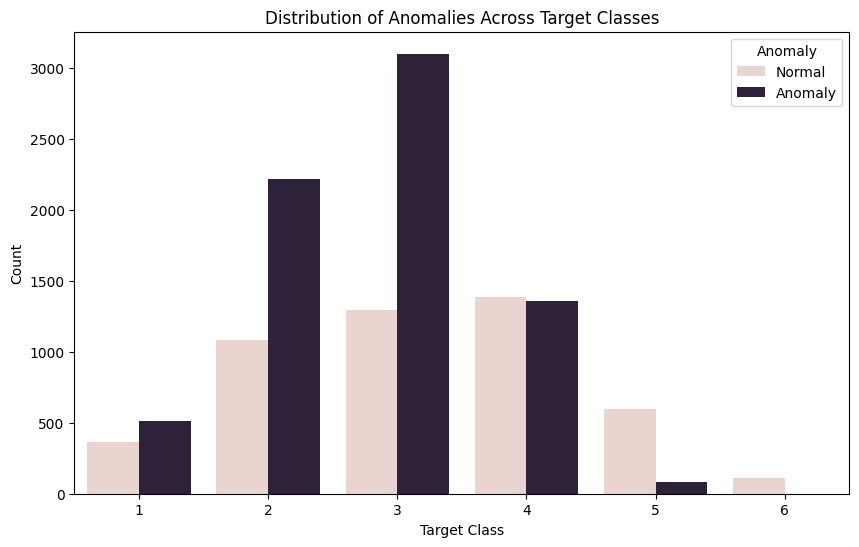

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of anomalies across different classes
plt.figure(figsize=(10, 6))
sns.countplot(x='target', hue='anomaly', data=anamolies)
plt.title('Distribution of Anomalies Across Target Classes')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.legend(title='Anomaly', labels=['Normal', 'Anomaly'])
plt.show()


In [162]:
# Drop anomalies from the training and validation data
X_train['target'] = y_train

X_test['target'] = y_test

X_train = X_train[X_train['anomaly'] == -1]

X_test = X_test[X_test['anomaly'] == -1]


y_train = X_train['target']

y_test = X_test['target']

X_train.drop(columns=['anomaly', 'target'], inplace=True)

X_test.drop(columns=['anomaly', 'target'], inplace=True)



/tmp/ipykernel_171146/677018570.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['target'] = y_train
/tmp/ipykernel_171146/677018570.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test['target'] = y_test


In [163]:
X_train

,essay_id,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,...,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199
14179,d0a986e,0.302412,0.917303,1.144956,0.011624,0.063050,-0.645707,-0.109022,-0.140292,-0.097996,...,-0.421736,-0.643975,-0.648376,0.313916,-0.600202,-0.713115,-1.005704,-0.594316,-0.641269,-0.201324
10517,9b3341c,0.302412,0.686718,0.745662,-0.171533,-0.275147,0.182727,-0.157908,-0.358092,0.167936,...,-0.421736,-0.616971,0.575062,-0.756854,-0.600202,1.046112,-0.493384,0.104192,2.330415,-0.666705
15382,e2926f9,0.302412,0.456134,-0.019652,-0.522582,-0.290520,-0.645707,-0.361425,-0.575893,-0.097996,...,-0.421736,-0.844528,0.083146,-0.030412,-0.600202,-0.713115,-0.133637,1.086423,0.247151,-0.035249
2820,2a161b2,-0.290758,-0.005035,-0.292503,-0.153217,-0.444246,0.115100,-0.289130,-0.053172,-0.097996,...,0.385359,-0.565569,0.101524,-0.756854,-0.600202,0.005758,-1.511421,-0.884885,0.269471,-0.666705
513,08669b6,-0.290758,1.609056,-0.325778,-0.176112,-0.505736,0.132007,-0.740472,-1.011494,-0.363928,...,0.479636,-0.844528,-0.648376,3.401551,-0.600202,-0.713115,-0.272662,-0.433508,-0.641269,-0.666705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7655,729b908,1.785338,0.686718,-0.418946,-1.128941,-0.797815,-0.882402,-0.585665,-0.924374,-0.230962,...,-0.421736,-0.474638,-0.648376,0.230580,1.661355,-0.713115,-0.701636,0.186934,0.566337,0.191617
462,07a14a5,0.005827,1.954932,2.722168,1.209466,2.661019,-0.256850,-0.012267,0.033948,-0.297445,...,-0.421736,-0.436735,-0.282966,2.871878,-0.184651,-0.362823,1.061267,-0.294060,0.690084,0.910423
4901,49080ed,-0.290758,-0.120327,0.392952,0.318410,0.063050,0.520864,0.118436,-0.009612,0.101453,...,-0.421736,-0.083895,0.033203,-0.756854,0.174901,-0.059736,1.576989,-0.884885,-0.641269,-0.078360
263,04a4c98,0.005827,-0.120327,-0.878135,-0.772285,-1.043777,-0.341384,-0.529989,-0.837253,-0.164479,...,-0.421736,0.144458,3.339518,1.883281,-0.600202,3.109780,-0.153007,-0.884885,-0.641269,0.480757


In [164]:
print(X_train.shape, y_train.shape)

(4846, 3008) (4846,)


In [165]:
feature_cols.append('anomaly')

# save the order of the column names to a txt file

with open(file_config['feature_cols'], 'w') as f:
    for item in feature_cols:
        f.write("%s\n" % item)

In [166]:
# Check if the file has been written correctly and is not empty
import os

scaler_path = file_config['scaler']

if os.path.getsize(scaler_path) > 0:

    print(f"Scaler saved successfully in {scaler_path}.")
    
else:

    print(f"Failed to save scaler to {scaler_path}. File is empty.")

Scaler saved successfully in /home/jack/github/kaggle/scoring/model_data/sklearn/scaler.pkl.


In [167]:
# Check if the scaler is StandardScaler
if isinstance(scaler, StandardScaler):
    print("The scaler is a StandardScaler.")
elif isinstance(scaler, MinMaxScaler):
    print("The scaler is a MinMaxScaler.")
else:
    print("The scaler is neither StandardScaler nor MinMaxScaler.")

The scaler is a StandardScaler.


In [168]:
# To convert features and targets to NumPy arrays for ML use

# train_features = X_train.values

# train_labels = np.array(train_labels.values)

# val_features = X_test.values

# val_labels = np.array(y_test.values)




# print("Features shape:", train_features.shape)
# print("Target shape:", train_labels.shape)

# print("Features shape:", val_features.shape)
# print("Target shape:", val_labels.shape)



#####     Features shape: (3, 1389)


In [169]:
import pandas as pd
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn import ensemble, model_selection, metrics
import numpy as np
import pickle
import os
from sklearn.base import clone
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import make_scorer, accuracy_score, cohen_kappa_score
import keras_tuner

# Function to compute Quadratic Weighted Kappa
def quadratic_weighted_kappa_scorer(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')

# Define the model building function for the tuner
def build_model(hp):
    model_type = hp.Choice('model_type', ['random_forest', 'gradient_boosting', 'lightgbm'])
    if model_type == 'random_forest':
        model = ensemble.RandomForestClassifier(
            n_estimators=hp.Int('n_estimators', 10, 100, step=10),
            max_depth=hp.Int('max_depth', 3, 20),
            min_samples_split=hp.Int('min_samples_split', 2, 20),
            min_samples_leaf=hp.Int('min_samples_leaf', 1, 10),
            criterion=hp.Choice('criterion', ['gini', 'entropy']),
            class_weight=hp.Choice('class_weight', ['balanced', 'balanced_subsample']),
            max_samples=hp.Float('max_samples', 0.1, 1.0, sampling='log'))
    elif model_type == 'gradient_boosting':
        model = ensemble.GradientBoostingClassifier(
            n_estimators=hp.Int('n_estimators', 50, 200, step=50),
            learning_rate=hp.Float('learning_rate', 0.01, 0.2, sampling='log'),
            max_depth=hp.Int('max_depth', 3, 15),
            subsample=hp.Float('subsample', 0.5, 1.0, step=0.1))
    else:  # LightGBM
        from lightgbm import LGBMClassifier
        model = LGBMClassifier(
            n_estimators=hp.Int('n_estimators', 50, 200, step=50),
            num_leaves=hp.Int('num_leaves', 31, 127, step=16),
            learning_rate=hp.Float('learning_rate', 0.01, 0.2, sampling='log'),
            min_child_samples=hp.Int('min_child_samples', 10, 50, step=10),
            max_depth=hp.Int('max_depth', 3, 15),  # Tunable max_depth parameter
            min_data_in_leaf=hp.Int('min_data_in_leaf', 20, 100, step=10),  # Increases the minimum data per leaf
            min_gain_to_split=hp.Float('min_gain_to_split', 0.001, 0.1, sampling='log'),  # Ensures splits bring gains
            lambda_l1=hp.Float('lambda_l1', 0.01, 10.0, sampling='log'),  # L1 regularization
            lambda_l2=hp.Float('lambda_l2', 0.01, 10.0, sampling='log'),  # L2 regularization
            force_col_wise=True,  # Force using column-wise calculation to avoid overhead
            class_weight='balanced'  # Handling class imbalance
        )
    return model





# Prepare data: Assuming X_train and y_train are already defined
X_train_original = X_train.drop(columns='essay_id').copy()  # Keep the original training data
y_train_original = y_train.drop(columns='essay_id').copy() 

# Apply SMOTE to balance the minority classes
smote = SMOTE(sampling_strategy='not minority', random_state=42)
X_train_upsampled, y_train_upsampled = smote.fit_resample(X_train_original, y_train_original)


In [181]:
# Tuner configuration
tuner = keras_tuner.tuners.SklearnTuner(
    oracle=keras_tuner.oracles.BayesianOptimizationOracle(
        objective=keras_tuner.Objective('score', 'max'),
        max_trials=5),
    hypermodel=build_model,
    scoring=make_scorer(quadratic_weighted_kappa_scorer),
    cv=model_selection.StratifiedKFold(5),
    directory='.',
    project_name='data/sklearn',
    overwrite=True)


# Tuning on the original data

# tuner.search(X_train_original.values, y_train_original.values)

tuner.search(X_train_upsampled.values, y_train_upsampled.values)


Trial 2 Complete [00h 00m 41s]
score: 0.9576347021414685

Best score So Far: 0.9576347021414685
Total elapsed time: 00h 11m 26s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
gradient_boosting |lightgbm          |model_type
20                |30                |n_estimators
6                 |15                |max_depth
3                 |19                |min_samples_split
2                 |3                 |min_samples_leaf
gini              |gini              |criterion
balanced_subsample|balanced          |class_weight
0.50454           |0.66098           |max_samples
0.068529          |0.053264          |learning_rate
0.6               |0.8               |subsample
63                |31                |num_leaves
40                |10                |min_child_samples
30                |20                |min_data_in_leaf
0.06074           |0.001             |min_gain_to_split
6.0252            |0.01              |lambda_l1
0.55775           |0

In [ ]:
# # apply smote within k-fold cross validation in order to avoid data leakage

# # Define the cross-validation strategy

# cv = model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# # Initialize the model
# model = ensemble.RandomForestClassifier(random_state=42)

# # Initialize the SMOTE object

# smote = SMOTE(sampling_strategy='not majority', random_state=42)

# # Initialize the StandardScaler
# scaler = StandardScaler()

# # Initialize the list to store the cross-validated scores

# cv_scores = []

# # Perform cross-validation

# for train_idx, val_idx in cv.split(X_train, y_train):

#     # Extract the training and validation data
#     X_train_fold, y_train_fold = X_train.iloc[train_idx], y_train.iloc[train_idx]
#     X_val_fold, y_val_fold = X_train.iloc[val_idx], y_train.iloc[val_idx]

#     # Apply SMOTE to the training data
#     X_train_resampled, y_train_resampled = smote.fit_resample(X_train_fold, y_train_fold)

#     # Scale the training and validation data
#     X_train_scaled = scaler.fit_transform(X_train_resampled)
#     X_val_scaled = scaler.transform(X_val_fold)

#     # Fit the model on the training data
#     model.fit(X_train_scaled, y_train_resampled)

#     # Predict the target on the validation data
#     y_pred = model.predict(X_val_scaled)

#     # Compute the Quadratic Weighted Kappa
#     qwk = quadratic_weighted_kappa_scorer(y_val_fold, y_pred)

#     # Append the score to the list
#     cv_scores.append(qwk)

# # Compute the average score

# cv_score = np.mean(cv_scores)

# # Print the average score

# print(f"Average Quadratic Weighted Kappa: {cv_score:.4f}")

# # Save the model

# with open(file_config['sklearn_model'], 'wb') as f:
#     pickle.dump(model, f)



In [ ]:
# Retrieve the best model
best_model = tuner.get_best_models(num_models=1)[0]

# Fit models on both upsampled and original data
model_standard = clone(best_model)
model_standard.fit(X_train_original, y_train_original)

model_upsampled = clone(best_model)
model_upsampled.fit(X_train_upsampled, y_train_upsampled)

# Ensemble using voting
ensemble_model = VotingClassifier(estimators=[
    ('standard', model_standard),
    ('upsampled', model_upsampled)
], voting='soft')



[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=50 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] lambda_l2 is set=0.3559225523424149, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.3559225523424149
[LightGBM] [Warning] min_gain_to_split is set=0.09732346788069235, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.09732346788069235
[LightGBM] [Warning] lambda_l1 is set=0.7200632487177211, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.7200632487177211
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=50 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] lambda_l2 is set=0.3559225523424149, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.3559225523424149
[LightGBM] [Warning] min_gain_to_split is set=0.09732346788069235, min_split_gain=0.0 will be ignored. Current value: m

In [ ]:
# Assuming X_val and y_val are your validation sets

best_model.fit(X_train_original, y_train_original)  # Optionally refit if necessary

ensemble_model.fit(X_train_original, y_train_original)  # Optionally refit if necessary

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=50 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] lambda_l2 is set=0.3559225523424149, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.3559225523424149
[LightGBM] [Warning] min_gain_to_split is set=0.09732346788069235, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.09732346788069235
[LightGBM] [Warning] lambda_l1 is set=0.7200632487177211, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.7200632487177211
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=50 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] lambda_l2 is set=0.3559225523424149, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.3559225523424149
[LightGBM] [Warning] min_gain_to_split is set=0.09732346788069235, min_split_gain=0.0 will be ignored. Current value: m

VotingClassifier(estimators=[('standard',
                              LGBMClassifier(class_weight='balanced',
                                             force_col_wise=True,
                                             lambda_l1=0.7200632487177211,
                                             lambda_l2=0.3559225523424149,
                                             learning_rate=0.0346709670186893,
                                             max_depth=13, min_child_samples=50,
                                             min_data_in_leaf=20,
                                             min_gain_to_split=0.09732346788069235,
                                             n_estimators=30, num_leaves=63)),
                             ('upsampled',
                              LGBMClassifier(class_weight='balanced',
                                             force_col_wise=True,
                                             lambda_l1=0.7200632487177211,
                                             lambda_l2=0.3559225523424149,
                                             learning_rate=0.0346709670186893,
                                             max_depth=13, min_child_samples=50,
                                             min_data_in_leaf=20,
                                             min_gain_to_split=0.09732346788069235,
                                             n_estimators=30, num_leaves=63))],
                 voting='soft')

In [ ]:
ensamble_predictions = ensemble_model.predict(X_test.drop(columns=['essay_id']))

# Evaluate and print results
print("Validation Accuracy:", accuracy_score(y_test, ensamble_predictions))
print("Validation Cohen's Kappa:", quadratic_weighted_kappa_scorer(y_test, ensamble_predictions))
print("Validation Quadratic Weighted Kappa:", quadratic_weighted_kappa_scorer(y_test, ensamble_predictions))
print("Validation Cohens Weighted Kappa:",cohen_kappa_score(y_test, ensamble_predictions, weights='quadratic'))

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=50 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] lambda_l2 is set=0.3559225523424149, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.3559225523424149
[LightGBM] [Warning] min_gain_to_split is set=0.09732346788069235, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.09732346788069235
[LightGBM] [Warning] lambda_l1 is set=0.7200632487177211, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.7200632487177211
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=50 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] lambda_l2 is set=0.3559225523424149, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.3559225523424149
[LightGBM] [Warning] min_gain_to_split is set=0.09732346788069235, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.09732346788069235
[LightGBM] [Warning] lambda_l1 is set=0.720

In [ ]:
predictions = best_model.predict(X_test.drop(columns=['essay_id']))

# Evaluate and print results
print("Validation Accuracy:", accuracy_score(y_test, predictions))
print("Validation Cohen's Kappa:", quadratic_weighted_kappa_scorer(y_test, predictions))
print("Validation Quadratic Weighted Kappa:", quadratic_weighted_kappa_scorer(y_test, predictions))
print("Validation Cohens Weighted Kappa:",cohen_kappa_score(y_test, predictions, weights='quadratic'))

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=50 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] lambda_l2 is set=0.3559225523424149, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.3559225523424149
[LightGBM] [Warning] min_gain_to_split is set=0.09732346788069235, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.09732346788069235
[LightGBM] [Warning] lambda_l1 is set=0.7200632487177211, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.7200632487177211
Validation Accuracy: 0.767056530214425
Validation Cohen's Kappa: 0.9045965610321168
Validation Quadratic Weighted Kappa: 0.9045965610321168
Validation Cohens Weighted Kappa: 0.9045965610321168


In [ ]:
# confusion matrix

from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, predictions)

array([[130,  15,   0,   1,   0,   0],
       [ 26, 406,  40,   7,   0,   0],
       [  3,  57, 391,  86,   6,   0],
       [  1,   3,  68, 435,  81,   4],
       [  0,   1,   2,  52, 181,  10],
       [  0,   0,   0,   1,  14,  31]])

In [ ]:
# classification report

from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           1       0.81      0.89      0.85       146
           2       0.84      0.85      0.84       479
           3       0.78      0.72      0.75       543
           4       0.75      0.73      0.74       592
           5       0.64      0.74      0.69       246
           6       0.69      0.67      0.68        46

    accuracy                           0.77      2052
   macro avg       0.75      0.77      0.76      2052
weighted avg       0.77      0.77      0.77      2052



In [ ]:
from joblib import dump, load

dump(best_model, file_config['sklearn_model'])


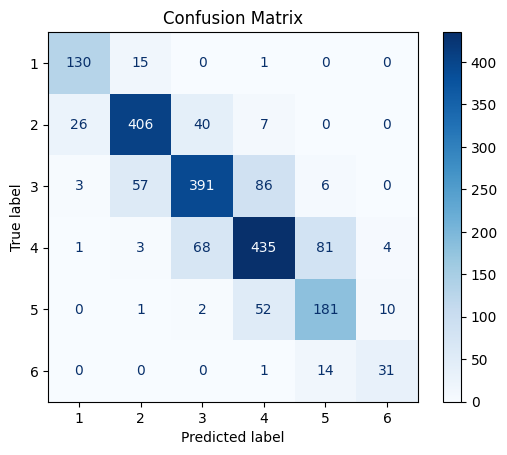

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate and display the confusion matrix for the test predictions
cm = confusion_matrix(y_test, predictions, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# X_test['predictions'] = predictions

# df_aggregated = X_test.groupby('essay_id')['predictions'].agg(lambda x: x.value_counts().index[0]).reset_index()

# df_aggregated.head()

In [ ]:
# import tensorflow_hub as hub
# import tensorflow as tf
# import os

# # Define the local path where the model will be saved
# model_dir = '/home/jack/github/kaggle/scoring/data/directory'

# # Ensure the directory exists
# os.makedirs(model_dir, exist_ok=True)

# # Download and save the model
# use_model = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
# tf.saved_model.save(use_model, model_dir)


In [ ]:
# get number of features from the model

# Get the number of features from the model

best_model = load(file_config['sklearn_model'])

# Get the number of features from the model

num_features = len(best_model.feature_importances_)

# Print the number of features

print(f"Number of features: {num_features}")

In [ ]:
# Identifying misclassified samples
misclassified_indices = (y_true != predictions)
misclassified_samples = val_features[misclassified_indices]
misclassified_true_labels = y_true[misclassified_indices]
misclassified_predicted_labels = predictions[misclassified_indices]


In [ ]:
# Examining features of misclassified samples
import pandas as pd
misclassified_df = pd.DataFrame(misclassified_samples)
misclassified_df['True_Label'] = misclassified_true_labels
misclassified_df['Predicted_Label'] = misclassified_predicted_labels
# Display the first few rows of the misclassified samples
misclassified_df.head()

In [ ]:
# # Feature importance from LightGBM
# feature_importance = best_model.feature_importance(importance_type='gain')
# feature_names = val_features.columns
# feature_importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': feature_importance
# })
# # Sort features by importance
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
# print(feature_importance_df)


In [ ]:
# Checking class distribution in the true labels
label_counts = pd.Series(y_true).value_counts()
print(label_counts)


In [ ]:
# from sklearn.model_selection import GridSearchCV
# # Define the hyperparameters to tune
# param_grid = {
#     'learning_rate': [0.01, 0.05, 0.1],
#     'num_leaves': [31, 62, 128],
#     'n_estimators': [50, 100, 200]
# }
# grid_search = GridSearchCV(best_model, param_grid, scoring='', cv=5)
# grid_search.fit(val_features, val_labels)
# print("Best parameters:", grid_search.best_params_)


In [ ]:
# Check LightGBM version
import lightgbm as lgb
print(lgb.__version__)


In [ ]:
# # Ensure the model is fitted
# if not hasattr(best_model, 'feature_importance_'):
#     best_model.fit(val_features, val_labels)  # Train or re-train the model

# # Retrieve feature importance
# feature_importance = best_model.feature_importance_  # Underscore at the end
# feature_names = val_features.columns

# # Create DataFrame for feature importance
# feature_importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': feature_importance
# })
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# print(feature_importance_df)


In [ ]:
# Assuming `df` is the original DataFrame and `predictions` is a list/array of predicted labels
# If there's a subset used for predictions, ensure it aligns with the DataFrame
val_df['Predicted_Label'] = predictions


In [ ]:
print(len(val_features), len(val_df), len(predictions))

In [ ]:
val_df.tail()

In [ ]:
# merge 'clean_text' column back with val df 

text = val_essays[['essay_id', 'clean_text']]

val_df = val_df.merge(text, on = 'essay_id')

val_df.head()

In [ ]:
# Assuming `df` has the original labels in a column named 'True_Label'
misclassified_samples = val_df[val_df['score'] != val_df['Predicted_Label']]

# Display misclassified samples
print(misclassified_samples[['score', 'Predicted_Label', 'clean_text']][:15])


In [ ]:
# Example: Analyze original text of misclassified samples
misclassified_text = misclassified_samples['clean_text']  # Assuming 'Text' is the original text data
print(misclassified_text.head())


In [ ]:
# load tf model
len(misclassified_text)

In [ ]:
# add full mis classified text to a txt file seperated by  '---' and a new line after every 10 words in each essay

with open('misclassified_text.txt', 'w') as f:
    for essay in misclassified_text:
        f.write("%s\n" % essay)
        f.write('---\n')
        


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Assuming `df` has your model's features and labels
X = val_df[feature_cols]
y = val_df['score'] == val_df['Predicted_Label']

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a RandomForest to see feature importances
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Get the most important features
importances = clf.feature_importances_
features = feature_cols
important_features = {features[i]: importances[i] for i in range(len(features))}

# convert to percentages rounded and sort

important_features = {k: round(v, 5) for k, v in important_features.items()}

print("Most predictive features of misclassification:", sorted(important_features.items(), key=lambda x: x[1], reverse=True))

In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Assume val_df and feature_cols are already defined

# # Set the option to display all rows
# pd.set_option('display.max_rows', None)

# # Selecting the features and the target
# X = val_df[feature_cols]
# y = val_df['score']

# # Calculate the correlation between features and the target
# corr = X.corrwith(y)

# # Sort the correlation values
# corr = corr.sort_values(ascending=False)

# # Convert the Series to a DataFrame for heatmap compatibility
# corr_df = pd.DataFrame(corr, columns=['Correlation'])

# corr_df


In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report

# # Define the feature set with and without the specific features
# X_with = val_df[feature_cols]  # including all features
# X_without = val_df.drop(columns=['misspelling_count', 'sentence_length'], axis=1) # excluding problematic features

# y = val_df['score']  # target variable

# # Split the data
# X_train_with, X_test_with, y_train, y_test = train_test_split(X_with, y, test_size=0.3, random_state=42)
# X_train_without, X_test_without, _ , _ = train_test_split(X_without, y, test_size=0.3, random_state=42)

# # Train models
# model_with = RandomForestClassifier().fit(X_train_with, y_train)
# model_without = RandomForestClassifier().fit(X_train_without, y_train)

# # Evaluate models
# print("With features:")
# print(classification_report(y_test, model_with.predict(X_test_with)))

# print("Without features:")
# print(classification_report(y_test, model_without.predict(X_test_without)))
